# Header: Sensitivity gradient for surveys of the HT-ATES site (version 1)

**Research setting:** hot water is injected into a shallow aquifer at the HT-ATES site in Delft. We investigate the use of a surface-to-borehole CSEM monitoring set-up for recovering the shape of the hot plume that develops.

**Based on:** The EASYGO summer school exercises: https://github.com/emsig/easygo-training-em/blob/main/emg3d_ATES.ipynb

## Version 1: Sensitivity gradient for FMv1.2 survey design USING EMG3D 1.9.1

We want to use a selection of sources determined through the v1.2 forward-modelling script. In the basic configuration, 6 sources are used which are both x- and y-directed. In this script, we compute the response to a buoyant hot plume generated in COMSOL.

Hot plume: generated through a COMSOL model for homogeneous aquifer (not site-specific)
Resistivity model: based on the interpretation by Marco Bortollotti

It will be of interest to see if there are changes in the measured signal at the receiver due to this hot plume that is not present at the receivers itself (a requirement for DTS-based monitoring). The survey design will be tested to investigate when this sensitivity is the highest.

We use the new 1.9.1 edition of Emg3d to separate gradient responses of individual sources and identify the most impactful combination, and also to test the effect of using different noise levels on the gradient

## Limitations

The receivers used in this forward-modeling are point-based receivers, which does not accurately represent the measurement. The real receivers will be of 0.5 m in length and spaced by 7.5 m. It was decided to implement the spacing (7.5 m) but not the size of the receivers for now. Source length is also not included in this version. Empymod could be used to test if the size of the receivers makes a difference to the measurement. It would also be good to consider the capacitive coupling of the receivers and whether this makes a difference to the acquired signal.

Additional investigations should include: comparison with surface-to-surface measurements, inversion of synthetic data, investigation of different survey designs, investigate impact of the production well steel casing and placing sources close to the production well (magnification of the source signal at depth), effect of well-deviation and Ex component, effect of vertical sources in DTS wells

# Code

In [1]:
import emg3d
import empymod
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from Emg3d_extra_grid_functions import *

plt.style.use('bmh')

# Comment this out on Google Colab
#%matplotlib widget

## Functions

In [2]:
#define interpolation functions
def find_distance2d(coord1, coord2):
    distance = (coord1[0]-coord2[0])**2+(coord1[1]-coord2[1])**2
    return distance
    #This is the distance squared but it should work the same

def interpolate2d(location, array):
    dis = []
    for i in np.arange(len(array)):
        dis.append(find_distance2d(location, array[i]))
    return np.argmin(dis)

### Selecting cuboids from the grid

In [3]:
def point2index_xyz(grid, point, QC=False):
    #Assumes that 
    
    x_spacing = min(grid.h[0])
    y_spacing = min(grid.h[1])
    z_spacing = min(grid.h[2])

    grid_center_i = int((grid.n_cells+grid.shape_cells[0]*grid.shape_cells[1]+ grid.shape_cells[0])/2)
    grid_center =  grid.cell_centers[grid_center_i]

    ix_steps = int((point[0]-grid_center[0])/x_spacing)
    iy_steps = int((point[1]-grid_center[1])/y_spacing)
    iz_steps = int((point[2]-grid_center[2])/z_spacing)
    
    ix = int(grid.shape_cells[0]/2)+ix_steps
    iy = int(grid.shape_cells[1]/2)+iy_steps
    iz = int(grid.shape_cells[2]/2)+iz_steps

    if grid.h[0][int(grid.shape_cells[0]/2)] != x_spacing:
        print('Warning: no homogeneous x-spacing')
    if grid.h[1][int(grid.shape_cells[1]/2)] != y_spacing:
        print('Warning: no homogeneous y-spacing')
    if grid.h[2][int(grid.shape_cells[2]/2)] != z_spacing:
        print('Warning: no homogeneous z-spacing')

    if QC==True:
        print('x: ', grid.cell_centers_x[ix])
        print('y: ', grid.cell_centers_y[iy])
        print('z: ', grid.cell_centers_z[iz])

    return ix, iy, iz

In [4]:
def find_cuboid_indeces_xyz(grid, x_extent, y_extent, zmin, zmax, QC=True):

    cornerpoint1 = [-x_extent, -y_extent, zmin]
    cornerpoint2 = [x_extent, y_extent, zmax]

    if QC==True:
        print(cornerpoint1, cornerpoint2)
    
    ix_min, iy_min, iz_min = point2index_xyz(grid, cornerpoint1, QC=False)
    ix_max, iy_max, iz_max = point2index_xyz(grid, cornerpoint2, QC=False)

    return ix_min, iy_min, iz_min, ix_max, iy_max, iz_max

In [5]:
def change_cuboid_resistivity(res_orig, grid, x_extent, y_extent, zmin, zmax, target_res):
    #Assumes that cuboid will be created around x=0 and y=0
    #Only works for grids that are symmetric around the origin in the number of cells

    ix_min, iy_min, iz_min, ix_max, iy_max, iz_max = find_cuboid_indeces_xyz(grid, x_extent, y_extent, zmin, zmax)

    #QC the bounds
    print('x bounds: ', grid.cell_centers_x[ix_min], ' , ', grid.cell_centers_x[ix_max])
    print('y_bounds: ', grid.cell_centers_y[iy_min], ' , ', grid.cell_centers_y[iy_max])
    print('z_bounds: ', grid.cell_centers_z[iz_min], ' , ', grid.cell_centers_z[iz_max])

    # Set target resistivity of the cuboid
    res_new = res_orig
    res_new[ix_min:ix_max, iy_min:iy_max, iz_min:iz_max] = target_res

    return res_new

### Manual plotting of values (vs. plot_slice)
This is done to enable comparison with empymod

To compare with empymod, we crop the field values to the inner domain by finding the boundary indeces.
Note: we can only use the inner domain where no cell stretching is taking place: y = [-300, 300], z = [-250, -5] & cell width is constant

Note about plotting:

When using plot_slice, the simulation output is interpolated to the cell centers, which results in a slightly different plot than when the output is directly plotted using matplotlib. Especially beneath the source this is visible, as the field value should be 0 there but this is not shown if the field value is not sampled (or interpolated) to that exact point.

I have chosen here to use the matplotlib plotting, and to accept the inaccuracy below the source, as this makes it easier to compare results between emg3d and empymod

In [6]:
def crop_to_domain(efield3D, grid, x_slice = 0, y_extent=300, zmin=-250, zmax=0):

    #This method assumes cell_centers are the relevant parameters
    ix_min, iy_min, iz_min, ix_max, iy_max, iz_max = find_cuboid_indeces_xyz(grid, x_slice, y_extent, zmin, zmax, QC=True)

    #QC the bounds
    print('x position: ', grid.nodes_x[ix_max])
    print('y_bounds: ', grid.nodes_y[iy_min], ' , ', grid.nodes_y[iy_max+1])
    print('z_bounds: ', grid.cell_centers_z[iz_min], ' , ', grid.cell_centers_z[iz_max])

    # Crop Ez field array
    crop_efield3D = efield3D.fz[ix_max, iy_min:iy_max+2, iz_min:iz_max+1]
    crop_efield3D = np.flip(np.transpose(crop_efield3D), axis=0)

    return crop_efield3D

In [7]:
def manual_plot_slice(efield, grid, y_extent=300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-7, vmax = 1e-6, norm = 'log'):
    
    fig, ax = plt.subplots()
    plt.imshow(np.abs(efield), extent = [0, size_y, 0, size_z], norm=norm, vmin = vmin, vmax = vmax)
    ax.set_title('Field')
    #ax.set_xlabel('Offset (km)')
    #ax.set_ylabel('Depth (1e2 m)')
    plt.colorbar(location='right', fraction=0.035)
    plt.xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    plt.yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    plt.grid(False)
    plt.show()

In [8]:
def manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-8, vmax = 1e-4):

    fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))

    ax1_plot = ax1.imshow(np.abs(efield1), extent = [0, size_y, 0, size_z], norm='log', vmin = vmin, vmax = vmax)
    ax1.set_title('Field 1 |Ez| (V/m)')
    ax1.set_xlabel('y (m)')
    ax1.set_ylabel('z (m)')
    plt.colorbar(ax1_plot, location='bottom')
    ax1.set_xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    ax1.set_yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    ax1.grid(False)
    
    ax2_plot = ax2.imshow(np.abs(efield2), extent = [0, size_y, 0, size_z], norm='log', vmin = vmin, vmax = vmax)
    ax2.set_title('Field 2 |Ez| (V/m)')
    ax2.set_xlabel('y (m)')
    ax2.set_ylabel('z (m)')
    plt.colorbar(ax2_plot, location='bottom')
    ax2.set_xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    ax2.set_yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    ax2.grid(False)
    
    ax3_plot = ax3.imshow(np.abs(efield3), extent = [0, size_y, 0, size_z], norm='log', vmin = vmin, vmax = vmax)
    ax3.set_title('Field 3 |Ez| (V/m)')
    ax3.set_xlabel('y (m)')
    ax3.set_ylabel('z (m)')
    plt.colorbar(ax3_plot, location='bottom')
    ax3.set_xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    ax3.set_yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    ax3.grid(False)

## Survey & grid for models >>> EDIT SURVEY DESIGN HERE

- The hot plume is centred at x=0, y=0
- Receiver is located at x=0, y=74
- Depth is negative!

In [2]:
# Create a survey

# Acquisition source frequencies (Hz)
frequencies = [1.0]

# Source coordinates, a survey consisting of 6 surface sources including y-directed and x-directed sources at 35-100 m distance
src_x = [0, 0, -75, -25, 75, 25]
src_y = [-25, 25, 50, 50, 50, 50]
src_z = [0, 0, 0, 0, 0, 0]
src_az = [90.0, 90.0, 0, 0, 0, 0]
src = emg3d.surveys.txrx_coordinates_to_dict(
        emg3d.TxElectricDipole,
        (src_x, src_y, src_z, src_az, 0.0)
)

colors = ['blue', 'green', 'red', 'pink', 'orange', 'magenta']

# Receiver positions, vertical z-directed point dipoles
rec_x = np.arange(1, 41)*0
rec_y = np.array([74]*40)
rec_z = np.arange(1,41)*-7.5
rec = emg3d.surveys.txrx_coordinates_to_dict(
        emg3d.RxElectricPoint,
        (rec_x, rec_y, rec_z, 0.0, 90.0)
)

In [3]:
survey = emg3d.surveys.Survey(
    name='Example survey, not used',  # Name of the survey
    sources=src,               # Source coordinates
    receivers=rec,             # Receiver coordinates
    frequencies=frequencies,   # Two frequencies
    # data=data,               # If you have observed data
    noise_floor=1e-15,
    relative_error=0.01,
)

# Let's have a look at the survey:
survey

:: Survey «Example survey, not used» ::

<xarray.Dataset> Size: 5kB
Dimensions:   (src: 6, rec: 40, freq: 1)
Coordinates:
  * src       (src) <U6 144B 'TxED-1' 'TxED-2' 'TxED-3' ... 'TxED-5' 'TxED-6'
  * rec       (rec) <U7 1kB 'RxEP-01' 'RxEP-02' ... 'RxEP-39' 'RxEP-40'
  * freq      (freq) <U3 12B 'f-1'
Data variables:
    observed  (src, rec, freq) complex128 4kB (nan+nanj) ... (nan+nanj)
Attributes:
    noise_floor:     1e-15
    relative_error:  0.01

In [4]:
grid = emg3d.construct_mesh(
    center=(0,0,0),                                 # Center of wanted grid
    frequency=frequencies[0],                            # Frequency we will use the grid for
    properties=[25, 1e8],                       # Reference resistivity
    domain=([-150, 150], [-300, 300], [-250, 0]),   # Domain in which we want precise results
    center_on_edge=True,
    min_width_limits = [10, 10, 5],
)
 
grid  # mesh info
#grid.plot_grid() # plotting the grid

TensorMesh: 983,040 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     80   -103,135.26    103,135.26     10.00 28,028.05    1.37
   y    128   -105,016.88    105,016.88     10.00 21,122.27    1.25
   z     96   -105,145.43    156,825.85      5.00 51,925.42    1.49

## Subsurface models >>> EDIT MODELS TO USE HERE

### Uniform halfspace model

In [5]:
#Uniform resistivity model with only air interface included and 33 Ohmm resistivity everywhere (average of Bortollotti values)
depth = [0]

# Layer resistivities in Ohm.m
resistivities_unif = np.array([1e8, 33.0]) # base incl. air (lower res, because of 3D modelling)

# Pre-allocate an array with number of cells corresponding to our grid
res = np.ones(grid.shape_cells)

# Layered base model: Fill in layered resistivities into our grid
dd = np.r_[np.inf, depth, -np.inf]
for i in range(len(resistivities_unif)):
    res[:, :, (grid.cell_centers_z > dd[i+1]) & (grid.cell_centers_z <= dd[i])] = resistivities_unif[i]

# Create the homogenous 25 kOhm model
model_unif = emg3d.Model(grid, property_x=res, mapping='Resistivity')

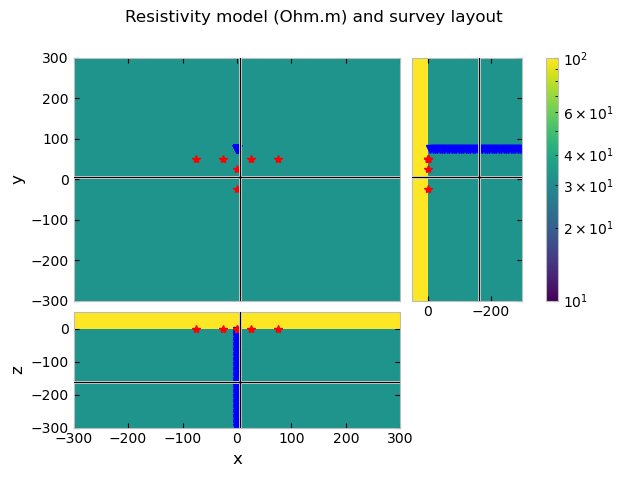

In [6]:
# Plot/QC the model
grid.plot_3d_slicer(
    model_unif.property_x,
    pcolor_opts={'norm': LogNorm(vmin=10, vmax=100)},
    xlim=[-300, 300],
    ylim=[-300, 300],
    zlim=[-300, 50],
    zslice=-160,
)
# Plot survey in figure above
fig = plt.gcf()
fig.suptitle('Resistivity model (Ohm.m) and survey layout')
axs = fig.get_children()
rec_coords = [rec_x, rec_y, rec_z]
axs[1].plot(rec_coords[0], rec_coords[1], 'bv')
axs[2].plot(rec_coords[0], rec_coords[2], 'bv')
axs[3].plot(rec_coords[2], rec_coords[1], 'bv')
src_coords = [src_x, src_y, src_z]
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

### Baseline layered model

In [7]:
#Baseline resistivity model from Bortolotti

# We idealize the depth model here a bit, to have cells of 10m in depth
depth = [0, -50, -80, -120, -190]

# Layer resistivities in Ohm.m for the baseline
resistivities_base = np.array([1e8, 52.0, 38.0, 26.0, 29.5, 17.5]) # base incl. air (lower res, because of 3D modelling)

# Pre-allocate an array with number of cells corresponding to our grid
res_base = np.ones(grid.shape_cells)

# Layered base model: Fill in layered resistivities into our grid and create model
dd = np.r_[np.inf, depth, -np.inf]
for i in range(len(resistivities_base)):
    res_base[:, :, (grid.cell_centers_z > dd[i+1]) & (grid.cell_centers_z <= dd[i])] = resistivities_base[i]

model_base = emg3d.Model(grid, property_x=res_base, mapping='Resistivity')

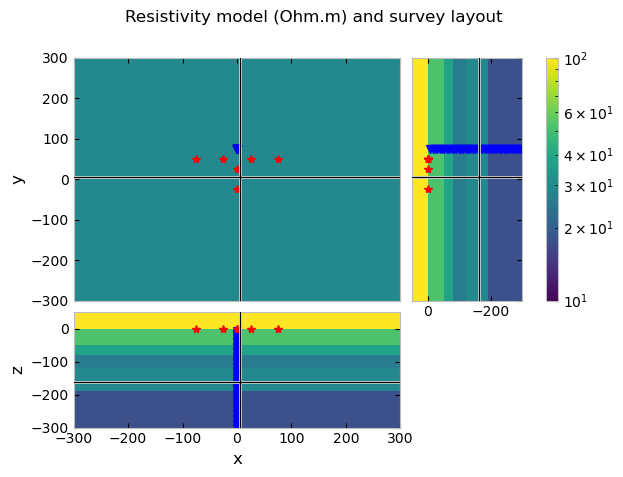

In [8]:
# Plot/QC the model
grid.plot_3d_slicer(
    model_base.property_x,
    pcolor_opts={'norm': LogNorm(vmin=10, vmax=100)},
    xlim=[-300, 300],
    ylim=[-300, 300],
    zlim=[-300, 50],
    zslice=-160,
)
# Plot survey in figure above
fig = plt.gcf()
fig.suptitle('Resistivity model (Ohm.m) and survey layout')
axs = fig.get_children()
rec_coords = [rec_x, rec_y, rec_z]
axs[1].plot(rec_coords[0], rec_coords[1], 'bv')
axs[2].plot(rec_coords[0], rec_coords[2], 'bv')
axs[3].plot(rec_coords[2], rec_coords[1], 'bv')
src_coords = [src_x, src_y, src_z]
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

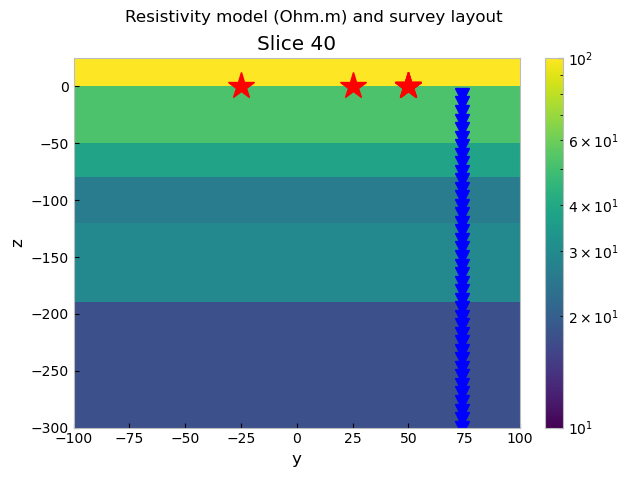

In [9]:
#Focus on the y,z plane
f0 = grid.plot_slice(
    model_base.property_x,
    normal = 'X',
    pcolor_opts={'norm': LogNorm(vmin=10, vmax=100)},
    range_x=[-100, 100],
    range_y=[-300, 25],
    slice_loc=0
)
fig = plt.gcf()
fig.suptitle('Resistivity model (Ohm.m) and survey layout')
axs = fig.get_children()
axs[1].plot(rec_coords[1], rec_coords[2], 'bv', markersize = 10)
axs[1].plot(src_coords[1], src_coords[2], 'r*', markersize = 20)
axs[1].grid(False)
fig.colorbar(f0[0], ax=axs[1], fraction=0.05, location='right')

### Hot plume generated in COMSOL

#### Insert custom plume

In [10]:
#Use predefined function to insert a cuboid inton the target layer

x_extent = 150
y_extent = 150
zmin = depth[4]
zmax = depth[3]
res_QC = 13.1 #now: aquifer +50 °Celsius

res_QC = change_cuboid_resistivity(res_base.copy(), grid, x_extent, y_extent, zmin, zmax, res_QC)

model_QC = emg3d.Model(grid, property_x=res_QC, mapping='Resistivity')

[-150, -150, -190] [150, 150, -120]
x bounds:  -145.0000000000176  ,  144.9999999999824
y_bounds:  -144.99999999999443  ,  145.00000000000557
z_bounds:  -187.49999999999577  ,  -117.49999999999577


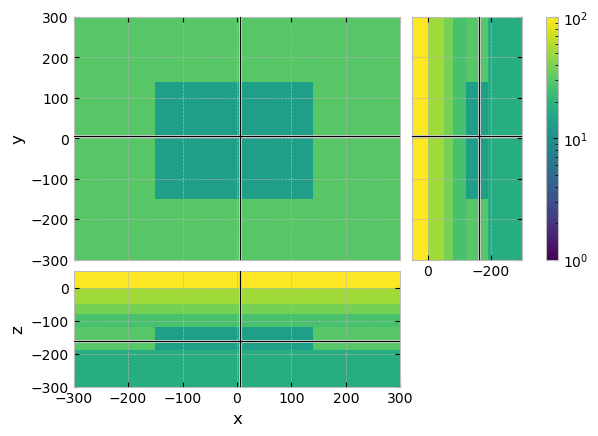

In [11]:
#QC cube location
grid.plot_3d_slicer(
    model_QC.property_x,
    pcolor_opts={'norm': LogNorm(vmin=1, vmax=100)},
    xlim=[-300, 300],
    ylim=[-300, 300],
    zlim=[-300, 50],
    zslice=-160,
)
fig = plt.gcf()

In [16]:
#insert custom hot plume values [SKIP TO NEXT STEP IF RES FILE IS ALREADY SAVED]

#Load custom plume data
comsol_plume = np.loadtxt('20260422_nonbuoyant_45days.txt', skiprows=8) #data columns: radius, depth, temperature (K)

print(np.shape(comsol_plume))

#crop data array to limit interpolation time
plume_crop = []
for i in np.arange(len(comsol_plume[:,0])):
    if comsol_plume[i,0] < 150 and comsol_plume[i,1] > depth[4] and comsol_plume[i,1] < depth[3]:
        plume_crop.append(comsol_plume[i])

print(np.shape(plume_crop))

ix_min, iy_min, iz_min, ix_max, iy_max, iz_max = find_cuboid_indeces_xyz(grid, x_extent, y_extent, zmin, zmax)

#interpolate temperature values and insert into 1d custom plume array
#To prevent edge effects, we assume that the min. temperature in the custom plume array is the original temperature of the aquifer before injection
rho_cold = resistivities_base[4]
T_cold = min(np.array(plume_crop)[:,2])
res_target3 = res_base.copy()
for ix in np.arange(ix_min, ix_max+1):
    for iy in np.arange(iy_min, iy_max+1):
        for iz in np.arange(iz_min, iz_max+1):
            loc = [grid.cell_centers_x[ix], grid.cell_centers_y[iy], grid.cell_centers_z[iz]] #select a cell coordinate from our grid
            radius = np.sqrt(loc[0]**2+loc[1]**2)
            loc2d = np.array([radius, loc[2]]) #flatten to 2d coordinates
            T_hot = plume_crop[interpolate2d(loc2d, plume_crop)][2] #find temperature value of COMSOL data point closest to this cell
            res_target3[ix, iy, iz] = rho_cold/(1+0.020*(T_hot-T_cold)) #translate to resistivity

#Save as new file in flattened form
np.savetxt('nonbuoyant_45days_interpolated.txt', res_target3.ravel('F'))

(37664, 3)
(3234, 3)
[-150, -150, -190] [150, 150, -120]


#### Load desired plume file

Possible plumes to use:
- 'test_plume_1_interpolated.txt': a small plume that reflects ... day injection in the default aquifer used by Gao et al.
- 'test_plume_2_interpolated.txt': a large plume that reflects ... day injection in the default aquifer used by Gao et al.

In [17]:
#load existing custom plume resistivities
res_target = np.loadtxt('nonbuoyant_45days_interpolated.txt')
#print(np.shape(res_plume))

model_target = emg3d.Model(grid, property_x=res_target, mapping='Resistivity')

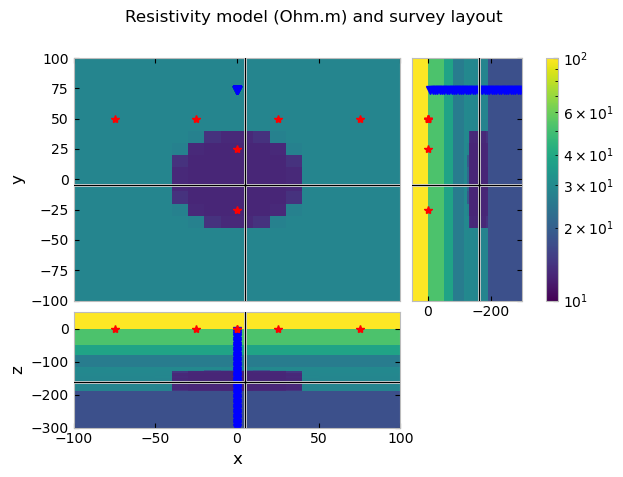

In [18]:
# Plot/QC the model with the 3D target
grid.plot_3d_slicer(
    model_target.property_x,
    pcolor_opts={'norm': LogNorm(vmin=10, vmax=100)},
    #xlim=[-300, 300],
    #ylim=[-300, 300],
    #zlim=[-300, 50],
    #zslice=-120,
    xlim=[-100, 100],
    ylim=[-100, 100],
    zlim=[-300, 50],
    zslice=-160,
    yslice = 0
)
# Plot survey in figure above
fig = plt.gcf()
fig.suptitle('Resistivity model (Ohm.m) and survey layout')
axs = fig.get_children()
rec_coords = [rec_x, rec_y, rec_z]
axs[1].plot(rec_coords[0], rec_coords[1], 'bv')
axs[2].plot(rec_coords[0], rec_coords[2], 'bv')
axs[3].plot(rec_coords[2], rec_coords[1], 'bv')
src_coords = [src_x, src_y, src_z]
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

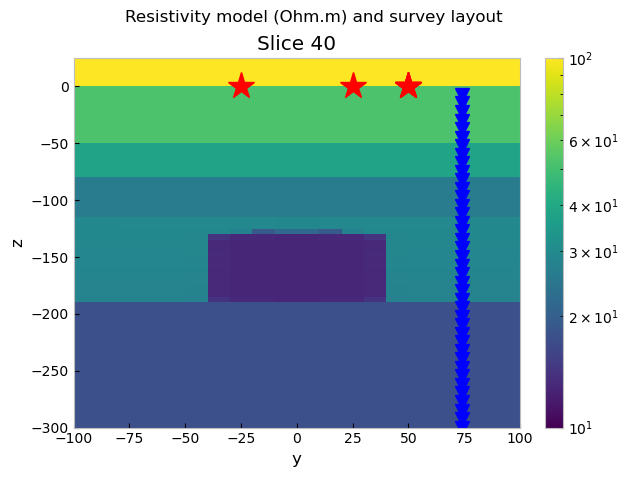

In [19]:
#Focus on the y,z plane
f0 = grid.plot_slice(
    model_target.property_x,
    normal = 'X',
    pcolor_opts={'norm': LogNorm(vmin=10, vmax=100)},
    range_x=[-100, 100],
    range_y=[-300, 25],
    slice_loc=0
)
fig = plt.gcf()
fig.suptitle('Resistivity model (Ohm.m) and survey layout')
axs = fig.get_children()
axs[1].plot(rec_coords[1], rec_coords[2], 'bv', markersize = 10)
axs[1].plot(src_coords[1], src_coords[2], 'r*', markersize = 20)
axs[1].grid(False)
fig.colorbar(f0[0], ax=axs[1], fraction=0.05, location='right')

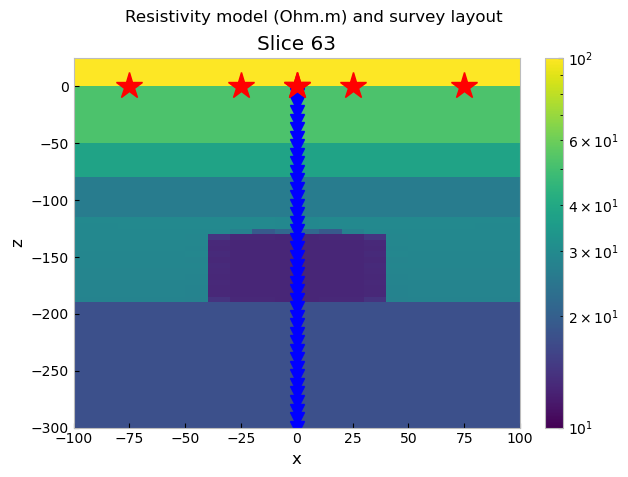

In [22]:
#Focus on the x,z plane
f0 = grid.plot_slice(
    model_target.property_x,
    normal = 'Y',
    pcolor_opts={'norm': LogNorm(vmin=10, vmax=100)},
    range_x=[-100, 100],
    range_y=[-300, 25],
    slice_loc=0
)
fig = plt.gcf()
fig.suptitle('Resistivity model (Ohm.m) and survey layout')
axs = fig.get_children()
axs[1].plot(rec_coords[0], rec_coords[2], 'bv', markersize = 10)
axs[1].plot(src_coords[0], src_coords[2], 'r*', markersize = 20)
axs[1].grid(False)
fig.colorbar(f0[0], ax=axs[1], fraction=0.05, location='right')

## Simulations

### Gridding options

The grid is adapted during the running of the Simulation, the below options are passed to the Simulation to constrain these grids

In [23]:
#Generate frequency- and source-dependent grids
gopts = {
    'properties': [25, 1e8],
    'min_width_limits': [10, 10, 5],
    #'stretching': (None, None, [1.0, 1.5]),
    'domain': (
        [-150, 150],
        [-300, 300],
        [-300, 0]
    ),
    'center_on_edge': False,
}

### Select which models to use where >>> EDIT SENSITIVITY DETAILS HERE

Two simulations are included:
- We test if it is possible to recover the baseline layered structure using the given survey design, by calculating the misfit and sensitivity gradient against a homogeneous halfspace 33 Ohmm starting model
- We test if it is possible to recover the hot plume model using the given survey design, (...)

**You can edit the below to investigate different things. All the calculations should then be automatically adapted.**

In [24]:
#Save models in a dictionary

models = {} # Contains [model, extended name
models['Uniform'] = [model_unif, 'Uniform halfspace 33 Ohmm']
models['Baseline'] = [model_base, 'Baseline layered model']
models['Target'] = [model_target, 'Layered model + COMSOL test plume 2']
#Values added later: survey containing the model and noise information

# Create a dictionary for the simulations to compute

simulations = {} # Contains [reference model key, measured model key]
simulations['Sensitivity target v base'] = ['Baseline', 'Target']
#Values added later: survey 1, simulation 1, survey 2, simulation 2, gradient

noise_floor = 1e-15
relative_error = 0.000001

In [25]:
#QC
print(models)

{'Uniform': [Model: resistivity; isotropic; 80 x 128 x 96 (983,040), 'Uniform halfspace 33 Ohmm'], 'Baseline': [Model: resistivity; isotropic; 80 x 128 x 96 (983,040), 'Baseline layered model'], 'Target': [Model: resistivity; isotropic; 80 x 128 x 96 (983,040), 'Layered model + COMSOL test plume 2']}


The following objects are used:
- **survey 1:** used to forward-model the measured data
- **simulation 1:** using compute(observed=True) to add the measured data to the survey as synthetic (no noise) and observed (with noise)
- **survey 2:** copy of survey 1 so initially contains the measured data with/wo noise, but used to forward-model the reference data and obtain gradient
- **simulation 2:** using compute() to add the reference data to the survey as synthetic only (no noise), compute the gradient between observed and synthetic

### Forward-modeling of the measured data

In [26]:
#Create a survey design to generate measured data for each model (they are all the same, but have different names)

for i in np.arange(len(simulations.keys())):
    sim_key = list(simulations.keys())[i]

    #The survey incorporates the src-rec positions and the noise recorded during measurement
    survey1 = emg3d.surveys.Survey(
        name='Survey 1: '+sim_key,  # Name of the survey
        sources=src,               # Source coordinates
        receivers=rec,             # Receiver coordinates
        frequencies=frequencies,   # Two frequencies
        # data=data,               # Adding the observed data here will allow sensitivity calculation later, but we need to generate it first
        noise_floor=noise_floor,
        relative_error=relative_error,
    )

    #Add surveys to model dictionary
    simulations[sim_key] = [simulations[sim_key][0], simulations[sim_key][1], survey1]

In [28]:
#QC survey 1, should not contain data at this point
sim_nr = 0

sim_key = list(simulations.keys())[sim_nr]
print(sim_key)
print(simulations[sim_key][2])

Sensitivity target v base
:: Survey «Survey 1: Sensitivity target v base» ::

<xarray.Dataset> Size: 5kB
Dimensions:   (src: 6, rec: 40, freq: 1)
Coordinates:
  * src       (src) <U6 144B 'TxED-1' 'TxED-2' 'TxED-3' ... 'TxED-5' 'TxED-6'
  * rec       (rec) <U7 1kB 'RxEP-01' 'RxEP-02' ... 'RxEP-39' 'RxEP-40'
  * freq      (freq) <U3 12B 'f-1'
Data variables:
    observed  (src, rec, freq) complex128 4kB (nan+nanj) ... (nan+nanj)
Attributes:
    noise_floor:     1e-15
    relative_error:  1e-06


In [29]:
# Create simulations (forward-modeling) for the models we want

for i in np.arange(len(simulations.keys())):
    sim_key = list(simulations.keys())[i]
    meas_model_key = simulations[sim_key][1]

    #The simulation class contains all that is needed to forward-model the measurement: survey, model, grid, and solving parameters
    simulation1 = emg3d.simulations.Simulation(
            name='Simulation 1: '+sim_key,    # A name for this simulation
            survey=simulations[sim_key][2],        # Our survey instance
            model=models[meas_model_key][0],          # The model
            gridding='both',      # Frequency- and source-dependent meshes
            max_workers=4,        # How many parallel jobs
            # solver_opts,        # Any parameter to pass to emg3d.solve
            gridding_opts=gopts,  # Gridding options
            receiver_interpolation = "linear" #Needed for correct computation of the gradient
        )

    simulation1.compute(observed=True)
    print('Measured data for: '+sim_key+' computed')
    #The version without noise is stored in the survey as 'synthetic' and version with noise as 'observed'

    #Add simulations to simulations dictionary
    simulations[sim_key] = [simulations[sim_key][0], simulations[sim_key][1], simulations[sim_key][2], simulation1]

Compute efields            0/6  [00:00]

Measured data for: Sensitivity target v base computed


In [30]:
plt.rcParams.update({'font.size':10})
plt.rcParams.update({'lines.linewidth':1.0})

In [31]:
#QC survey 1, should now contain data
sim_nr = 0

sim_key = list(simulations.keys())[sim_nr]
print(sim_key)
print(simulations[sim_key][2])

Sensitivity target v base
:: Survey «Survey 1: Sensitivity target v base» ::

<xarray.Dataset> Size: 9kB
Dimensions:    (src: 6, rec: 40, freq: 1)
Coordinates:
  * src        (src) <U6 144B 'TxED-1' 'TxED-2' 'TxED-3' ... 'TxED-5' 'TxED-6'
  * rec        (rec) <U7 1kB 'RxEP-01' 'RxEP-02' ... 'RxEP-39' 'RxEP-40'
  * freq       (freq) <U3 12B 'f-1'
Data variables:
    observed   (src, rec, freq) complex128 4kB (-1.5136561372656196e-06+4.236...
    synthetic  (src, rec, freq) complex128 4kB (-1.5136574319884458e-06+4.229...
Attributes:
    noise_floor:     1e-15
    relative_error:  1e-06


#### Plots for QC of forward-models

(1e-10, 0.001)

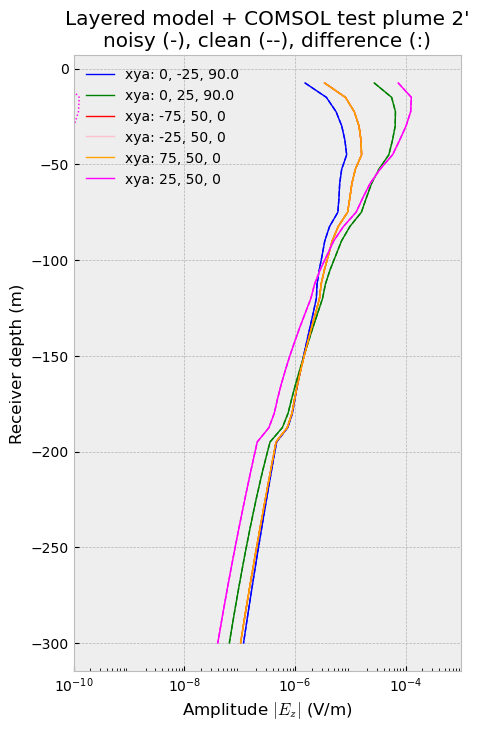

In [32]:
#QC receiver lines for all the sources

sim_nr = 0

sim_key = list(simulations.keys())[sim_nr]
simulation = simulations[sim_key][3]
model_name = models[simulations[sim_key][1]][1]

plt.figure(figsize=(5,8))
plt.title(''''''+model_name+''''
noisy (-), clean (--), difference (:)''')
noisy = simulation.data.observed[:, :, :]
clean = simulation.data.synthetic[:, :, :]
noise = noisy - clean
for i, srcn in enumerate(simulation.survey.sources):
    for ii, freq in enumerate(simulation.survey.frequencies):
        plt.plot(np.abs(noisy.loc[srcn, :, freq].data),
                 rec_coords[2][:],
                color = colors[i],
                 label='xya: '+str(src_x[i])+', '+str(src_y[i])+', '+str(src_az[i]) # else None
                 )
        plt.plot(np.abs(clean.loc[srcn, :, freq].data),
                 rec_coords[2][:],
                 '--',
                 color = colors[i],
                 )
        plt.plot(np.abs(noise.loc[srcn, :, freq].data),
         rec_coords[2][:],
         ':',
         color = colors[i],
         )
plt.xscale('log')
plt.legend(ncol=1, framealpha=0)
plt.ylabel('Receiver depth (m)')
plt.xlabel('Amplitude $|E_z|$ (V/m)')
ticks, labels = plt.xticks()
plt.xticks(ticks[1:-1])
plt.xlim([1e-10, 1e-3])

#The relative noise dominates and has amplitude of 1% of the data

[0, -300, -250] [0, 300, 0]
x position:  -4.999999999986301
y_bounds:  -299.99999999999443  ,  300.00000000000557
z_bounds:  -249.99999999998926  ,  -4.999999999989257
[0, -300, -250] [0, 300, 0]
x position:  -4.999999999986301
y_bounds:  -299.99999999999443  ,  300.00000000000557
z_bounds:  -249.99999999998926  ,  -4.999999999989257
[0, -300, -250] [0, 300, 0]
x position:  -4.999999999986301
y_bounds:  -299.99999999999443  ,  300.00000000000557
z_bounds:  -249.99999999998926  ,  -4.999999999989257


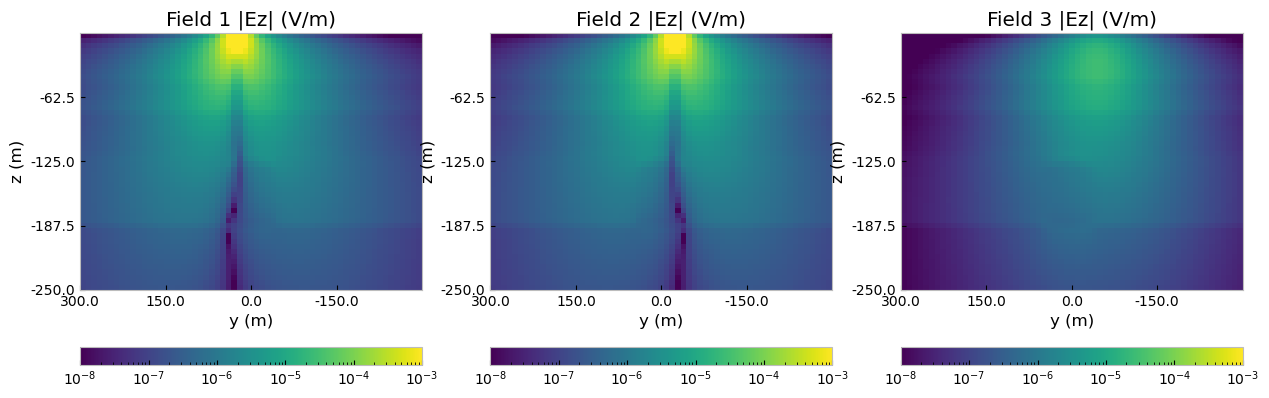

In [33]:
#QC total efields for different sources

sim_nr = 0
src_nr_1 = 0
src_nr_2 = 1
src_nr_3 = 2
fr_nr = 0

sim_key = list(simulations.keys())[sim_nr]
simulation = simulations[sim_key][3]
new_grid = simulation.get_grid(list(src)[src_nr_1], frequencies[fr_nr])
efield1 = simulation.get_efield(list(src)[src_nr_1], frequencies[fr_nr])
efield2 = simulation.get_efield(list(src)[src_nr_2], frequencies[fr_nr])
efield3 = simulation.get_efield(list(src)[src_nr_3], frequencies[fr_nr])
efield1 = crop_to_domain(efield1, new_grid, x_slice = 0, y_extent=300, zmin=-250, zmax=0)
efield2 = crop_to_domain(efield2, new_grid, x_slice = 0, y_extent=300, zmin=-250, zmax=0)
efield3 = crop_to_domain(efield3, new_grid, x_slice = 0, y_extent=300, zmin=-250, zmax=0)

manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-8, vmax = 1e-3)
#edit_manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-8, vmax = 1e-3)

### Forward-modeling of reference model

The survey we generated before now has observed data in it. We can continue with forward-modeling the reference (initial model) whilst this data (and the noise it contains) is encoded in the survey class.

In [34]:
#For clarity, we create a second survey that we can update

for i in np.arange(len(simulations.keys())):
    sim_key = list(simulations.keys())[i]
    survey1 = simulations[sim_key][2]
    survey2 = survey1.copy()
    
    #Add simulations to simulations dictionary
    simulations[sim_key] = [simulations[sim_key][0], simulations[sim_key][1], simulations[sim_key][2], simulations[sim_key][3], survey2]

In [35]:
#QC survey 2, should contain the same data as survey1
sim_nr = 0

sim_key = list(simulations.keys())[sim_nr]
print(sim_key)
print(simulations[sim_key][4])

Sensitivity target v base
:: Survey «Survey 1: Sensitivity target v base» ::

<xarray.Dataset> Size: 9kB
Dimensions:    (src: 6, rec: 40, freq: 1)
Coordinates:
  * src        (src) <U6 144B 'TxED-1' 'TxED-2' 'TxED-3' ... 'TxED-5' 'TxED-6'
  * rec        (rec) <U7 1kB 'RxEP-01' 'RxEP-02' ... 'RxEP-39' 'RxEP-40'
  * freq       (freq) <U3 12B 'f-1'
Data variables:
    observed   (src, rec, freq) complex128 4kB (-1.5136561372656196e-06+4.236...
    synthetic  (src, rec, freq) complex128 4kB (-1.5136574319884458e-06+4.229...
Attributes:
    noise_floor:     1e-15
    relative_error:  1e-06


In [36]:
#Now do forward-modeling to replace the synthetic data in survey2 with the reference model (the observd data remains)

for i in np.arange(len(simulations.keys())):
    sim_key = list(simulations.keys())[i]
    ref_model_key = simulations[sim_key][0]

    #The simulation contains the measured data (through the survey) and the details needed to forward-model the reference
    simulation2 = emg3d.simulations.Simulation(
        name='Simulation 2: '+sim_key,    # A name for this simulation
        survey=simulations[sim_key][4],        # Our survey instance
        model=models[ref_model_key][0],      # The model
        gridding='both',      # Frequency- and source-dependent meshes
        max_workers=4,        # How many parallel jobs
        # solver_opts,        # Any parameter to pass to emg3d.solve
        gridding_opts=gopts,  # Gridding options
        receiver_interpolation = "linear" # Needed for correct computation of the gradient
    )

    #Note here the observed = False is default, so that only the synthetic data stored in the survey is updated
    simulation2.compute()
    print('Reference data for: '+sim_key+' computed')

    #Calculate gradient for all sources combined - disabled to allow gradient calculation for each source individually later
    #gradient = simulation2.gradient
    #print('Gradient for: '+sim_key+' computed')

    #Add to dictionary
    simulations[sim_key] = [simulations[sim_key][0], simulations[sim_key][1], simulations[sim_key][2], simulations[sim_key][3], simulations[sim_key][4], simulation2]

Compute efields            0/6  [00:00]

Reference data for: Sensitivity target v base computed


In [37]:
#QC survey 1, should still contain just the measured data
sim_nr = 0

sim_key = list(simulations.keys())[sim_nr]
print(sim_key)
print(simulations[sim_key][2])

Sensitivity target v base
:: Survey «Survey 1: Sensitivity target v base» ::

<xarray.Dataset> Size: 9kB
Dimensions:    (src: 6, rec: 40, freq: 1)
Coordinates:
  * src        (src) <U6 144B 'TxED-1' 'TxED-2' 'TxED-3' ... 'TxED-5' 'TxED-6'
  * rec        (rec) <U7 1kB 'RxEP-01' 'RxEP-02' ... 'RxEP-39' 'RxEP-40'
  * freq       (freq) <U3 12B 'f-1'
Data variables:
    observed   (src, rec, freq) complex128 4kB (-1.5136561372656196e-06+4.236...
    synthetic  (src, rec, freq) complex128 4kB (-1.5136574319884458e-06+4.229...
Attributes:
    noise_floor:     1e-15
    relative_error:  1e-06


In [38]:
#QC survey 2, should now have the synthetic replaced by the reference model data and contain the measured data in observed
sim_nr = 0

sim_key = list(simulations.keys())[sim_nr]
print(sim_key)
print(simulations[sim_key][4])

Sensitivity target v base
:: Survey «Survey 1: Sensitivity target v base» ::

<xarray.Dataset> Size: 9kB
Dimensions:    (src: 6, rec: 40, freq: 1)
Coordinates:
  * src        (src) <U6 144B 'TxED-1' 'TxED-2' 'TxED-3' ... 'TxED-5' 'TxED-6'
  * rec        (rec) <U7 1kB 'RxEP-01' 'RxEP-02' ... 'RxEP-39' 'RxEP-40'
  * freq       (freq) <U3 12B 'f-1'
Data variables:
    observed   (src, rec, freq) complex128 4kB (-1.5136561372656196e-06+4.236...
    synthetic  (src, rec, freq) complex128 4kB (-1.5114899763314297e-06+4.227...
Attributes:
    noise_floor:     1e-15
    relative_error:  1e-06


#### Plots for QC of forward-models reference

We can compare synthetic (reference model) data and observed (true model) data as included in simulation2. This is done below.

But it won't tell us whether the difference is due to noise in the data or due to the models actually being different.

([<matplotlib.axis.XTick at 0x1c363e9cf50>,
 [Text(1e-10, 0, '$\\mathdefault{10^{-10}}$'),
  Text(1e-09, 0, '$\\mathdefault{10^{-9}}$'),
  Text(1e-08, 0, '$\\mathdefault{10^{-8}}$'),
  Text(1e-07, 0, '$\\mathdefault{10^{-7}}$'),
  Text(1e-06, 0, '$\\mathdefault{10^{-6}}$'),
  Text(1e-05, 0, '$\\mathdefault{10^{-5}}$'),
  Text(0.0001, 0, '$\\mathdefault{10^{-4}}$'),
  Text(0.001, 0, '$\\mathdefault{10^{-3}}$')])

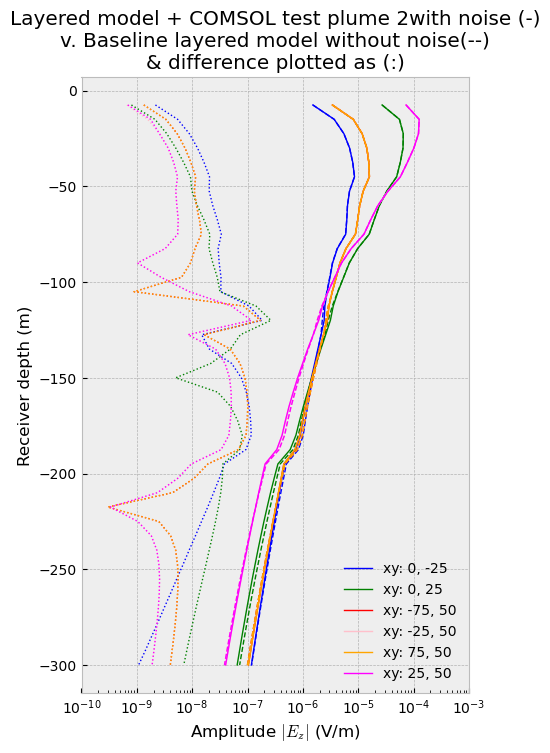

In [39]:
#QC reference receiver lines

sim_nr = 0

sim_key = list(simulations.keys())[sim_nr]
simulation2 = simulations[sim_key][5]
model_name = models[simulations[sim_key][1]][1]
ref_name = models[simulations[sim_key][0]][1]

plt.figure(figsize=(5,8))
plt.title(''''''+model_name+'''with noise (-)
v. '''+ref_name+''' without noise(--)
& difference plotted as (:)''')
meas = simulation2.data.observed[:, :, :]
ref = simulation2.data.synthetic[:, :, :]
diff = meas - ref
for i, srcn in enumerate(simulation.survey.sources.keys()):
    for ii, freq in enumerate(simulation.survey.frequencies):
        plt.plot(np.abs(meas.loc[srcn, :, freq].data),
                 rec_coords[2][:],
                 c=colors[i],
                 label='xy: '+str(src_x[i])+', '+str(src_y[i]) # else None
                 )
        plt.plot(np.abs(ref.loc[srcn, :, freq].data),
                 rec_coords[2][:],
                 '--',
                 color = colors[i],
                 #label = 'clean'
                 )
        plt.plot(np.abs(diff.loc[srcn, :, freq].data),
         rec_coords[2][:],
         ':',
         color = colors[i],
         #label = 'noise'
         )
plt.xscale('log')
plt.legend(ncol=1, framealpha=0)
plt.ylabel('Receiver depth (m)')
plt.xlabel('Amplitude $|E_z|$ (V/m)')
ticks, labels = plt.xticks()
plt.xticks(ticks[1:-1])

#The relative noise dominates and has amplitude of 1% of the data

Now we plot the difference between the two models in case there is no noise, in order to see if the difference is dominated by the noise. We take the noise-free model from simulation1, which was used to forward-model the measured data and which contains the noise-free measured data as 'synthetic'.

Later we also calculate the gradient for both cases.

([<matplotlib.axis.XTick at 0x1c36469f4d0>,
 [Text(1e-10, 0, '$\\mathdefault{10^{-10}}$'),
  Text(1e-09, 0, '$\\mathdefault{10^{-9}}$'),
  Text(1e-08, 0, '$\\mathdefault{10^{-8}}$'),
  Text(1e-07, 0, '$\\mathdefault{10^{-7}}$'),
  Text(1e-06, 0, '$\\mathdefault{10^{-6}}$'),
  Text(1e-05, 0, '$\\mathdefault{10^{-5}}$'),
  Text(0.0001, 0, '$\\mathdefault{10^{-4}}$'),
  Text(0.001, 0, '$\\mathdefault{10^{-3}}$')])

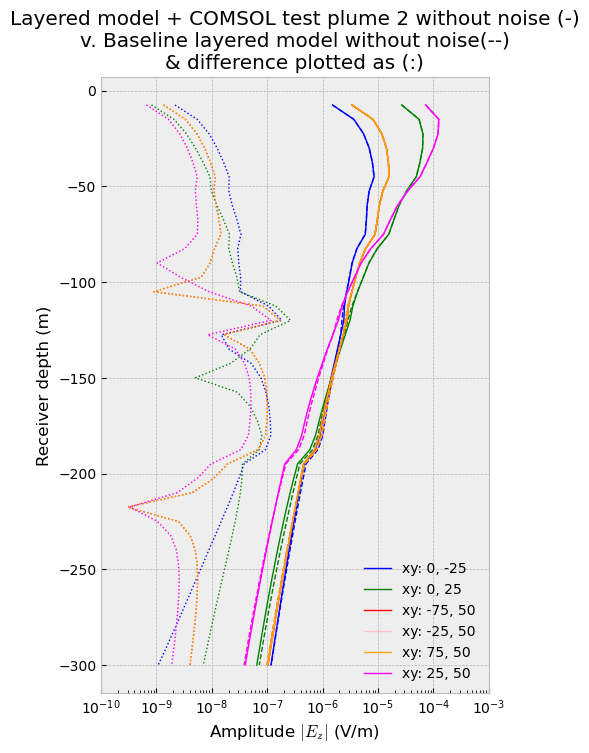

In [40]:
#QC reference receiver lines

sim_nr = 0

sim_key = list(simulations.keys())[sim_nr]
simulation1 = simulations[sim_key][3]
simulation2 = simulations[sim_key][5]
model_name = models[simulations[sim_key][1]][1]
ref_name = models[simulations[sim_key][0]][1]

plt.figure(figsize=(5,8))
plt.title(''''''+model_name+''' without noise (-)
v. '''+ref_name+''' without noise(--)
& difference plotted as (:)''')
meas = simulation1.data.synthetic[:, :, :]
ref = simulation2.data.synthetic[:, :, :]
diff = meas - ref
for i, srcn in enumerate(simulation.survey.sources.keys()):
    for ii, freq in enumerate(simulation.survey.frequencies):
        plt.plot(np.abs(meas.loc[srcn, :, freq].data),
                 rec_coords[2][:],
                 c=colors[i],
                 label='xy: '+str(src_x[i])+', '+str(src_y[i]) # else None
                 )
        plt.plot(np.abs(ref.loc[srcn, :, freq].data),
                 rec_coords[2][:],
                 '--',
                 color = colors[i],
                 #label = 'clean'
                 )
        plt.plot(np.abs(diff.loc[srcn, :, freq].data),
         rec_coords[2][:],
         ':',
         color = colors[i],
         #label = 'noise'
         )
plt.xscale('log')
plt.legend(ncol=1, framealpha=0)
plt.ylabel('Receiver depth (m)')
plt.xlabel('Amplitude $|E_z|$ (V/m)')
ticks, labels = plt.xticks()
plt.xticks(ticks[1:-1])

#The relative noise dominates and has amplitude of 1% of the data

In [41]:
for i in np.arange(len(src_x)):
    print('source_nr '+str(i)+': x = '+str(src_x[i])+', y = '+str(src_y[i])+', az = '+str(src_az[i]))

source_nr 0: x = 0, y = -25, az = 90.0
source_nr 1: x = 0, y = 25, az = 90.0
source_nr 2: x = -75, y = 50, az = 0
source_nr 3: x = -25, y = 50, az = 0
source_nr 4: x = 75, y = 50, az = 0
source_nr 5: x = 25, y = 50, az = 0


[0, -300, -250] [0, 300, 0]
x position:  -1.759303813742008e-11
y_bounds:  -304.99999999999903  ,  295.00000000000097
z_bounds:  -249.99999999998926  ,  -4.999999999989257
[0, -300, -250] [0, 300, 0]
x position:  -1.759303813742008e-11
y_bounds:  -304.99999999999903  ,  295.00000000000097
z_bounds:  -249.99999999998926  ,  -4.999999999989257


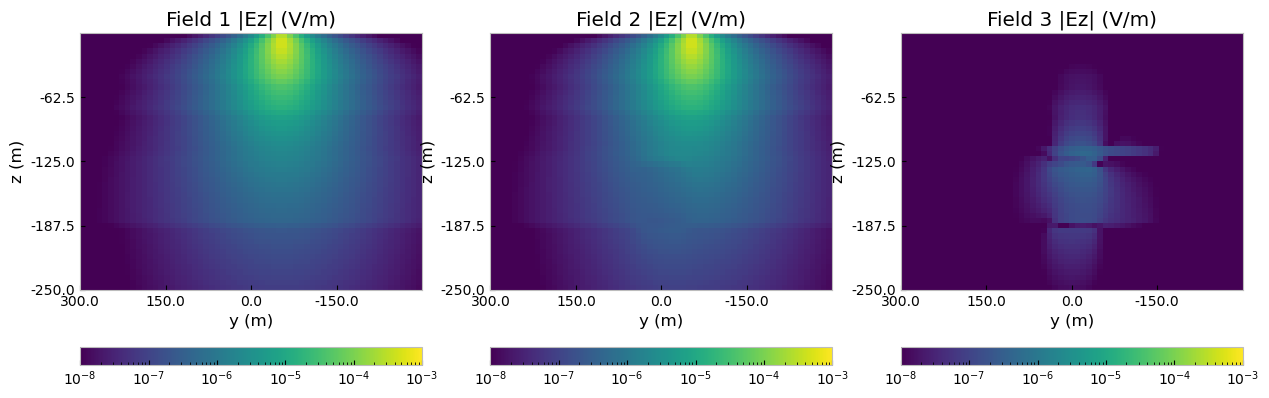

In [42]:
sim_nr = 0
src_nr = 5
fr_nr = 0

sim_key = list(simulations.keys())[sim_nr]
simulation = simulations[sim_key][3]
simulation2 = simulations[sim_key][5]
new_grid = simulation.get_grid(list(src)[src_nr], frequencies[fr_nr])
efield_ref = simulation2.get_efield(list(src)[src_nr], frequencies[fr_nr])
efield_meas = simulation.get_efield(list(src)[src_nr], frequencies[fr_nr])

efield1 = crop_to_domain(efield_ref, new_grid, x_slice = 0, y_extent=300, zmin=-250, zmax=0)
efield2 = crop_to_domain(efield_meas, new_grid, x_slice = 0, y_extent=300, zmin=-250, zmax=0)
efield3 = np.abs(efield2)-np.abs(efield1)

manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-8, vmax = 1e-3)
#edit_manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-8, vmax = 1e-3)

## Gradient calculation

We now have all the desired information we need stored in simulation2: the electromagnetic field for the reference model, the observed data based on the true subsurface model, the survey configuration and the noise levels which were added to this data.

We now create selections of the simulation2 simulation to identify the response of individual sources (made possible with emg3d v.1.9.0). Then we can calculate the gradient for each source.

Secondly, we change the observed data coupled to simulation2 instance to investigate the effect of using different noise levels in the survey (also made possible with v1.9.0)

### Gradients per source contribution

In [43]:
#We create a dictionary that mirrors the simulation dictionary but only contains gradients

gradients = {} # Contains [reference model key, measured model key, gradients with noise, gradients without noise]
gradients['Sensitivity target v base'] = ['Baseline', 'Target']
#gradients['Sensitivity base v unif'] = ['Uniform', 'Baseline']

In [43]:
#survey3_dict = survey3.to_dict()
#print(survey3_dict.keys())
#print(survey3_dict['data'])

In [44]:
#Now calculate the gradients for each source in a noisy and noise-free case

for i in np.arange(len(simulations.keys())):
    sim_key = list(simulations.keys())[i]
    simulation2 = simulations[sim_key][5]
    ref_model_key = simulations[sim_key][0]
    data_meas = simulations[sim_key][3].data.synthetic
    gradients_clean = []

    for j, srcn in enumerate(simulation.survey.sources.keys()):
        for jj, freq in enumerate(simulation.survey.frequencies):
            sim_j = simulation2.select(sources=srcn, frequencies=freq)
            grad_clean_j = sim_j.gradient
            print('Gradient for clean survey: '+sim_key+', source: ', j, ' out of ', len(simulation.survey.sources.keys()), ' computed')
            gradients_clean.append(grad_clean_j)

    #Add to dictionary
    gradients[sim_key] = [gradients[sim_key][0], gradients[sim_key][1], gradients_clean]

Back-propagate            0/1  [00:00]

Gradient for noisy survey: Sensitivity target v base, source:  0  out of  6  computed


Back-propagate            0/1  [00:00]

Gradient for noisy survey: Sensitivity target v base, source:  1  out of  6  computed


Back-propagate            0/1  [00:00]

...

Gradient for noisy survey: Sensitivity target v base, source:  3  out of  6  computed


Back-propagate            0/1  [00:00]

Gradient for noisy survey: Sensitivity target v base, source:  4  out of  6  computed


Back-propagate            0/1  [00:00]

Gradient for noisy survey: Sensitivity target v base, source:  5  out of  6  computed


## Saving and loading results

In [51]:
#Save results in a .npy file

filename = 'results_20260422_sensitivity_gradient_v1_5'

#Save the dictionaries used, use np.load('filename.npy').item() to retrieve the dictionary
np.save(filename+'_MODELS.npy', models)
np.save(filename+'_SIMULATIONS.npy', simulations) #Note this file also contains the surveys
np.save(filename+'_GRADIENTS.npy', gradients)

In [51]:
#Load gradients and QC them

filename = 'results_20260421_sensitivity_gradient_v1_4'
models = np.load(filename+'_MODELS.npy', allow_pickle=True).item()
simulations = np.load(filename+'_SIMULATIONS.npy', allow_pickle=True).item()
gradients = np.load(filename+'_GRADIENTS.npy', allow_pickle=True).item()

#Check the models used and simulations performed
print('Keys of the model dictionary (models generated): ', models.keys())
print('Keys of the simulations dictionary (simulations performed) ', simulations.keys())
print('Keys of the gradients dictionary (should match the simulations keys) ', gradients.keys())

#Print information on models and noise used
for i in np.arange(len(simulations.keys())):
    sim_key = list(simulations.keys())[i]
    print('Simulation ', i, 'of ', sim_key)
    print('Reference model: ', simulations[sim_key][0])
    print('True model: ', simulations[sim_key][1])
    simulation2 = simulations[sim_key][5] #We use simulation2 as this was the simulation used to forward-model the reference and compute the gradient
    #simulation1 = simulations[sim_key][3] #This can be used to check forward-modeling of the measured data from the true model
    survey2 = simulation2.survey
    survey2_dict = survey2.to_dict()
    print('Noise floor: ', survey2_dict['noise_floor'])
    print('Relative error: ', survey2_dict['relative_error'])
    print('First value of synthetic data: ', survey2.data.synthetic[0,0,0])
    print('First value of observed data: ', survey2.data.observed[0,0,0])

#Print information about the gradients included
for i in np.arange(len(gradients.keys())):
    grad_key = gradients.keys()[i]
    print('Gradient ', i, 'of ', grad_key)
    print('Reference model: ', gradients[grad_key][0])
    print('True model: ', gradients[grad_key][1])
    print('Computed for ', len(gradients[grad_key][2]), 'source/frequency combinations')
    print('First value of noisy survey gradient: ', gradients[grad_key][2][0][0])
    print('First value of clean survey gradient: ', gradients[grad_key][3][0][0])

Keys of the model dictionary (models generated):  dict_keys(['Uniform', 'Baseline', 'Target'])
Keys of the simulations dictionary (simulations performed)  dict_keys(['Sensitivity target v base', 'Sensitivity base v unif'])
Keys of the gradients dictionary (should match the simulations keys)  dict_keys(['Sensitivity target v base', 'Sensitivity base v unif'])
Simulation  0 of  Sensitivity target v base
Reference model:  Baseline
True model:  Target
Noise floor:  1e-15
Relative error:  0.01
First value of synthetic data:  <xarray.DataArray 'synthetic' ()> Size: 16B
array(-1.51148998e-06+4.22725115e-10j)
Coordinates:
    src      <U6 24B 'TxED-1'
    rec      <U7 28B 'RxEP-01'
    freq     <U3 12B 'f-1'
First value of observed data:  <xarray.DataArray 'observed' ()> Size: 16B
array(-1.51632674e-06-1.40876304e-08j)
Coordinates:
    src      <U6 24B 'TxED-1'
    rec      <U7 28B 'RxEP-01'
    freq     <U3 12B 'f-1'
Simulation  1 of  Sensitivity base v unif
Reference model:  Uniform
True mod

TypeError: 'dict_keys' object is not subscriptable

## Results

In [46]:
sim_nr = 0
sim_key = list(simulations.keys())[sim_nr]
selected_gradients= [0, 1, 2, 3, 4, 5] #This indicates the amount of sources included in the plotted gradient

gradient_list = gradients[sim_key][2]
print(np.shape(gradient_list))
gradient_flat = np.sum(gradients[sim_key][2], axis=0).ravel('F')
#gradient_flat = gradients[sim_key][2+noise_index][4].ravel('F')
print(np.shape(gradient_flat))
rel_gradient = np.divide(gradient_flat, max(gradient_flat))

(6, 80, 128, 96)
(983040,)


In [47]:
#Determine title of the plots

#if noise_index == 0:
#    title = 'Relative gradient '+sim_key+' including '+str(relative_error*100)+'% noise'
#else:
title = 'Relative gradient '+sim_key+' neglecting noise'

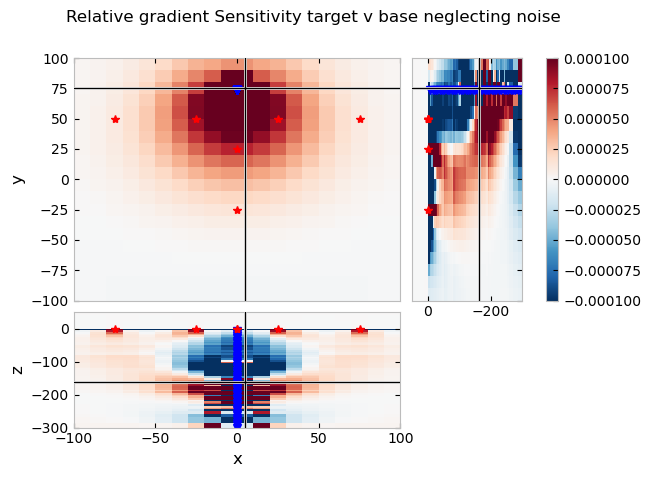

In [48]:
#Plot the gradient

#Set the gradient of air and water to NaN, this will eventually move directly into emgd3 (active and inactive cells).
#subsurface = (res < 1e3)
#grad[~subsurface] = np.nan

grid.plot_3d_slicer(
        rel_gradient,
        pcolor_opts={'cmap': 'RdBu_r',
                     'norm': Normalize(vmin=-1e-4, vmax=1e-4)},
        xlim=[-100, 100],
        ylim=[-100, 100], #center at receiver location
        zlim=[-300, 50],
        zslice=-160,
        yslice = 74)
fig = plt.gcf()
fig.suptitle(title)
axs = fig.get_children()
rec_coords = [rec_x, rec_y, rec_z]
axs[1].plot(rec_coords[0], rec_coords[1], 'bv')
axs[2].plot(rec_coords[0], rec_coords[2], 'bv')
axs[3].plot(rec_coords[2], rec_coords[1], 'bv')
src_coords = [src_x, src_y, src_z]
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

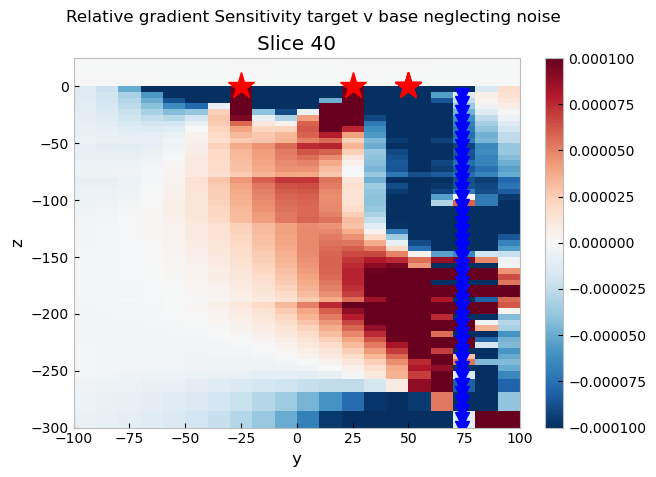

In [49]:
#Focus on the y,z plane (x=0)

f0 = grid.plot_slice(
    rel_gradient,
    pcolor_opts={'cmap': 'RdBu_r',
             'norm': Normalize(vmin=-1e-4, vmax=1e-4)},
    normal = 'X',
    range_x=[-100, 100], #y extent
    range_y=[-300, 25], #z extent
    slice_loc=0 #, defaults to 0
)
fig = plt.gcf()
fig.suptitle(title)
axs = fig.get_children()
axs[1].grid(False)
rec_coords = survey.receiver_coordinates()
src_coords = survey.source_coordinates()
axs[1].plot(rec_coords[1], rec_coords[2], 'bv', markersize = 10)
axs[1].plot(src_coords[1], src_coords[2], 'r*', markersize = 20)
fig.colorbar(f0[0], ax=axs[1], fraction=0.05, location='right')

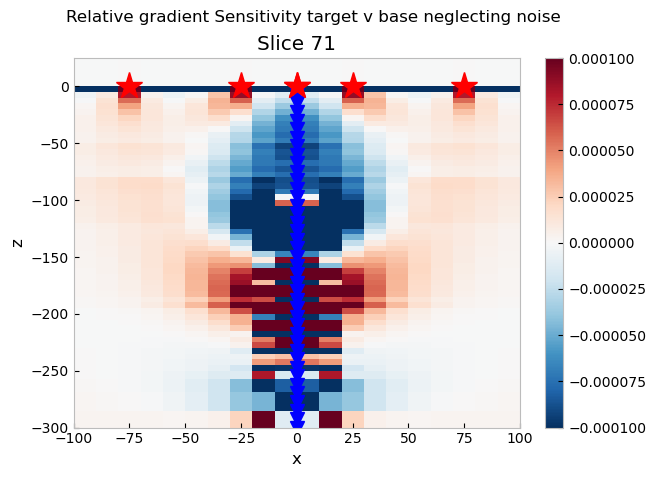

In [50]:
#Focus on the x,z plane (y=74)

f0 = grid.plot_slice(
    rel_gradient,
    pcolor_opts={'cmap': 'RdBu_r',
             'norm': Normalize(vmin=-1e-4, vmax=1e-4)},
    normal = 'Y',
    range_x=[-100, 100], #y extent
    range_y=[-300, 25], #z extent
    slice_loc=74 #, defaults to 0
)
fig = plt.gcf()
fig.suptitle(title)
axs = fig.get_children()
axs[1].grid(False)
rec_coords = survey.receiver_coordinates()
src_coords = survey.source_coordinates()
axs[1].plot(rec_coords[0], rec_coords[2], 'bv', markersize = 10)
axs[1].plot(src_coords[0], src_coords[2], 'r*', markersize = 20)
fig.colorbar(f0[0], ax=axs[1], fraction=0.05, location='right')

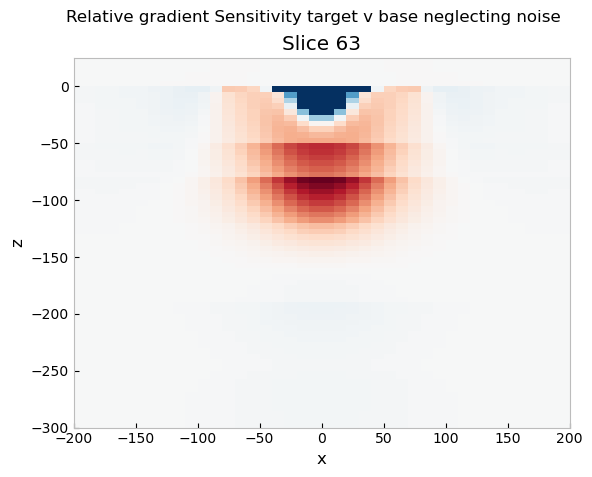

In [74]:
#Focus on the x,z plane (y=0)

grid.plot_slice(
    rel_gradient,
    pcolor_opts={'cmap': 'RdBu_r',
             'norm': Normalize(vmin=-1e-4, vmax=1e-4)},
    normal = 'Y',
    range_x=[-200, 200], #y extent
    range_y=[-300, 25], #z extent
    slice_loc=0 #, defaults to 0
)
fig = plt.gcf()
fig.suptitle(title)
axs = fig.get_children()
axs[1].grid(False)
rec_coords = survey.receiver_coordinates()
src_coords = survey.source_coordinates()
#axs[1].plot(rec_coords[1], rec_coords[2], 'bv', markersize = 10)
#axs[1].plot(src_coords[1], src_coords[2], 'r*', markersize = 20)

QC test below

In [ ]:
#Plot the simulated electric field

sim_nr = 0
src_nr = 3
fr_nr = 0

sim_key = list(simulations.keys())[sim_nr]
simulation1 = simulations[sim_key][3]
simulation2 = simulations[sim_key][5]
efield = simulation2.get_efield(list(src)[src_nr], frequencies[fr_nr])

new_grid.plot_3d_slicer(
    efield.fz.ravel('F'),
    view='imag',
    v_type='Ez',
    pcolor_opts={'norm': LogNorm(vmin=1e-10, vmax=1e-5)},
    xlim=[-300, 300],
    ylim=[-300, 300],
    zlim=[-300, 0],
    zslice=-160,
    yslice=0
)
# Plot survey in figure above
fig = plt.gcf()
fig.suptitle('Efield, |Ez| (V/m)')
axs = fig.get_children()
rec_coords = [rec_x, rec_y, rec_z]
src_coords = [src_x, src_y, src_z]
axs[1].plot(rec_coords[0], rec_coords[1], 'bv')
axs[2].plot(rec_coords[0], rec_coords[2], 'bv')
axs[3].plot(rec_coords[2], rec_coords[1], 'bv')
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

In [ ]:
emg3d.Report()